In [ ]:
# =========================================
# REGRESIÓN LINEAL - ÓXIDO NITROSO
# Autor: Juan José Velasco
# Notebook: Validacion de supuestos
# =========================================

In [ ]:
# Validación de Supuestos del Modelo

#En este notebook se validan los supuestos fundamentales del modelo de regresión lineal seleccionado previamente.

#La validación se realizará mediante herramientas gráficas y pruebas de hipótesis estadísticas con el propósito de verificar la adecuación del modelo lineal para explicar las emisiones de óxido nitroso.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import shapiro

from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

sns.set(style="whitegrid")

In [13]:
# Cargar el dataset
df = pd.read_excel("../data/oxido nitroso.xls")


# Renombrar columnas con nombres limpios para la regresión
df.columns = [
    "NOx",        # Óxido nitroso
    "Humidity",     # Humedad relativa
    "Temp",        # Temperatura
    "Pressure"   # Presión atmosférica
]


# Ajustar el modelo de regresión lineal simple
modelo_h = smf.ols("NOx ~ Humidity", data=df).fit()

In [10]:
# Obtener los residuos y los valores ajustados
residuos = modelo_h.resid
ajustados = modelo_h.fittedvalues


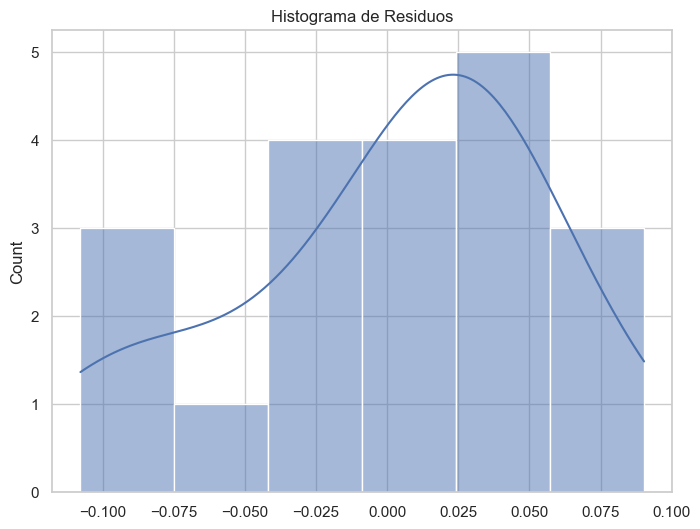

In [ ]:
# Validar normalidad de residuos con histograma
plt.figure(figsize=(8,6))

sns.histplot(residuos, kde=True)

plt.title("Histograma de Residuos")

plt.show()

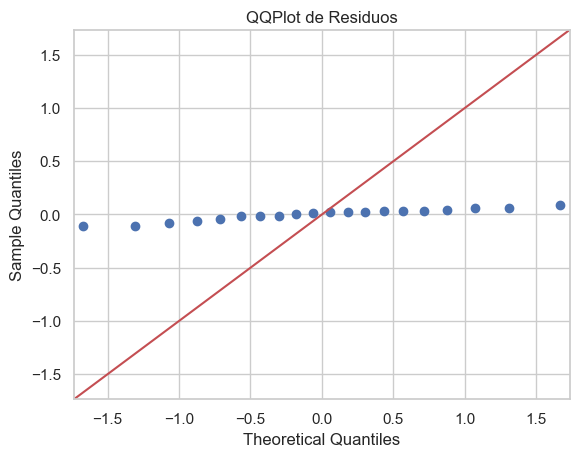

In [ ]:
#QQPlot de residuos
sm.qqplot(residuos, line='45')

plt.title("QQPlot de Residuos")

plt.show()

In [ ]:
# Prueba de Shapiro-Wilk

#H₀: Los residuos siguen una distribución normal.

#H₁: Los residuos no siguen una distribución normal.

In [ ]:
# Realizar la prueba de Shapiro-Wilk para normalidad de los residuos
stat, p = shapiro(residuos)

print("Estadístico:", stat)
print("p-value:", p)

alpha = 0.05

if p > alpha:
    print("No se rechaza H0.")
    print("Los residuos pueden considerarse normales.")
else:
    print("Se rechaza H0.")

Estadístico: 0.9355340645692403
p-value: 0.19719206579825593
No se rechaza H0.
Los residuos pueden considerarse normales.


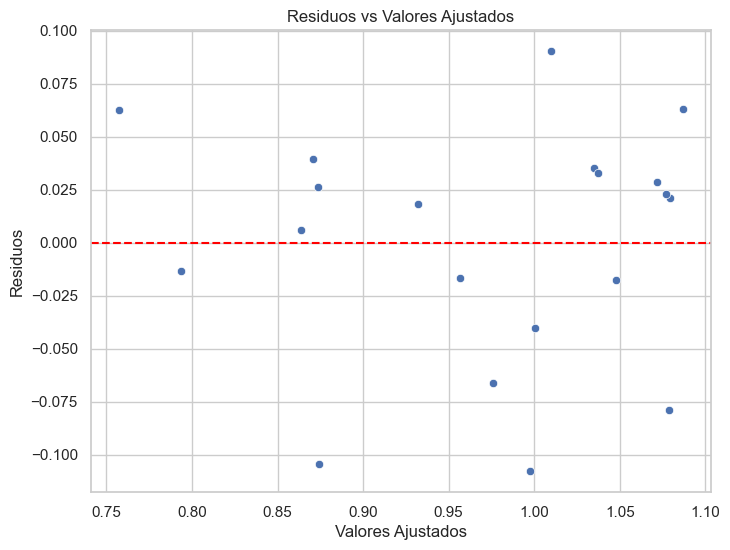

In [ ]:
# Análisis gráfico de residuos vs valores ajustados
plt.figure(figsize=(8,6))

sns.scatterplot(x=ajustados, y=residuos)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos")

plt.title("Residuos vs Valores Ajustados")

plt.show()

In [ ]:
# Prueba de Breusch-Pagan

#H₀: Existe homocedasticidad.

#H₁: Existe heterocedasticidad.

In [ ]:
# Realizar la prueba de Breusch-Pagan para homocedasticidad
bp_test = het_breuschpagan(residuos, modelo.model.exog)

labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

for name, value in zip(labels, bp_test):
    print(name, value)
p_bp = bp_test[1]

if p_bp > 0.05:
    print("No se rechaza H0.")
    print("Se cumple homocedasticidad.")
else:
    print("Se rechaza H0.")

LM Statistic 0.00028980636289865913
LM-Test p-value 0.986417708616182
F-Statistic 0.0002608295061109844
F-Test p-value 0.9872922191476716
No se rechaza H0.
Se cumple homocedasticidad.


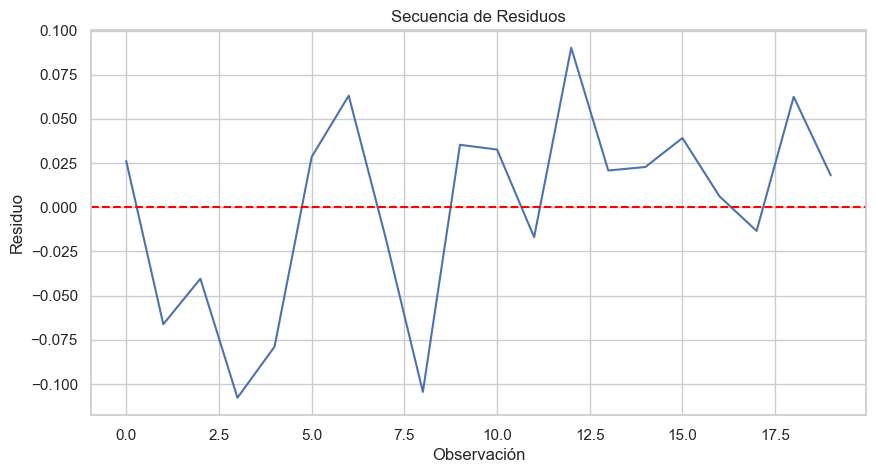

Durbin-Watson: 1.5306810275730958
Los residuos pueden considerarse independientes.


In [23]:
# Prueba de Durbin-Watson para autocorrelación de residuos
plt.figure(figsize=(10,5))

plt.plot(residuos)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Secuencia de Residuos")

plt.xlabel("Observación")
plt.ylabel("Residuo")

plt.show()
dw = durbin_watson(residuos)

print("Durbin-Watson:", dw)
if 1.5 < dw < 2.5:
    print("Los residuos pueden considerarse independientes.")
else:
    print("Existe posible autocorrelación.")

In [ ]:
# Conclusiones

# Los residuos del modelo presentan un comportamiento aproximadamente normal, tanto gráficamente
# como según la prueba de Shapiro-Wilk.
# El análisis gráfico de residuos y la prueba de Breusch-Pagan indican evidencia de homocedasticidad.
# El estadístico Durbin-Watson sugiere independencia entre los residuos del modelo.
# En general, los supuestos fundamentales del modelo de regresión lineal se consideran razonablemente
# válidos para este conjunto de datos.